<a href="https://colab.research.google.com/github/Nayra-Naara/classificacao-diabetes-knn-random-forest/blob/main/analise_e_classificacao_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho Parcial - Ciência de Dados e Inteligência Artificial**

## **Ciência de Dados**


#### Importações

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import kagglehub
import ipywidgets as widgets

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

#### Carregamento do Dataset

In [2]:
# Download do dataset
path = kagglehub.dataset_download("imtkaggleteam/diabetes")
print("Caminho:", path)

# Caminho completo do arquivo CSV
arquivo_csv = os.path.join(path, "diabetes.csv")

# Carregar e preservar os dados originais
df_original = pd.read_csv(arquivo_csv)

100%|██████████| 11.2k/11.2k [00:00<00:00, 2.82MB/s]

Extracting files...
Caminho: /root/.cache/kagglehub/datasets/imtkaggleteam/diabetes/versions/1


#### Pré-processamento dos Dados

In [3]:
df_original.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [4]:
# Copia os dados e traduz o cabeçalho
df = df_original.copy().rename(columns={
    'chol': 'Colesterol Total',
    'stab.glu': 'Glicose Estabilizada',
    'hdl': 'HDL',
    'ratio': 'Relação Colesterol/HDL',
    'location': 'Localidade',
    'age': 'Idade',
    'gender': 'Gênero',
    'height': 'Altura',
    'weight': 'Peso',
    'frame': 'Porte Corporal',
    'bp.1s': 'Pressão Sistólica 1',
    'bp.1d': 'Pressão Diastólica 1',
    'bp.2s': 'Pressão Sistólica 2',
    'bp.2d': 'Pressão Diastólica 2',
    'waist': 'Cintura',
    'hip': 'Quadril',
    'time.ppn': 'Tempo Após Refeição (min)'
})

df.head()

,id,Colesterol Total,Glicose Estabilizada,HDL,Relação Colesterol/HDL,glyhb,Localidade,Idade,Gênero,Altura,Peso,Porte Corporal,Pressão Sistólica 1,Pressão Diastólica 1,Pressão Sistólica 2,Pressão Diastólica 2,Cintura,Quadril,Tempo Após Refeição (min)
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [5]:
# Remove as linhas em que 'glyhb' está sem valor
shape_original = df.shape

df = df.dropna(subset=['glyhb']).copy()
print("Shape antes: ", shape_original, "\nShape depois: ", df.shape)

Shape antes:  (403, 19) 
Shape depois:  (390, 19)


In [6]:
# Adiciona coluna 'Diabetes' com base no valor de 'glyhb'
# Se 'glyhb' >=  6.5  ->   Sim
# Se 'glyhb' <  6.5   ->   Não
df['Diabetes'] = (df['glyhb'] >= 6.5).map({
    True: 'Sim',
    False: 'Não'
})

# Visualização dos dados
df.head()

,id,Colesterol Total,Glicose Estabilizada,HDL,Relação Colesterol/HDL,glyhb,Localidade,Idade,Gênero,Altura,Peso,Porte Corporal,Pressão Sistólica 1,Pressão Diastólica 1,Pressão Sistólica 2,Pressão Diastólica 2,Cintura,Quadril,Tempo Após Refeição (min),Diabetes
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0,Não
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0,Não
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0,Não
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0,Não
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0,Sim


#### Análise Exploratória nos Dados (EDA)

##### Pré-processamento de Dados

In [7]:
print("(linhas, colunas) =", df.shape)
print("\n\nInformações gerais dos dados:\n")
df.info()

(linhas, colunas) = (390, 20)


Informações gerais dos dados:

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 401
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         390 non-null    int64  
 1   Colesterol Total           389 non-null    float64
 2   Glicose Estabilizada       390 non-null    int64  
 3   HDL                        389 non-null    float64
 4   Relação Colesterol/HDL     389 non-null    float64
 5   glyhb                      390 non-null    float64
 6   Localidade                 390 non-null    object 
 7   Idade                      390 non-null    int64  
 8   Gênero                     390 non-null    object 
 9   Altura                     385 non-null    float64
 10  Peso                       389 non-null    float64
 11  Porte Corporal             379 non-null    object 
 12  Pressão Sistólica 1        385 non-null    float

Contagem de nulos em cada coluna

In [8]:
display(df.isna().sum())

,0
id,0
Colesterol Total,1
Glicose Estabilizada,0
HDL,1
Relação Colesterol/HDL,1
glyhb,0
Localidade,0
Idade,0
Gênero,0
Altura,5


As colunas ‘id’ e ‘Localidade’ serão removidas para priorizar as características clínicas e corporais. ‘Pressão Sistólica 2’ e ‘Pressão Diastólica 2’ serão excluídas por apresentarem 252 valores ausentes cada.

In [9]:
# Seleciona os dados para a análise, excluindo as colunas abaixo
dados_eda = df.drop(columns=[
    'Diabetes',
    'id',
    'glyhb',
    'Localidade',
    'Pressão Sistólica 2',
    'Pressão Diastólica 2'
])

# Lista com todas as colunas selecionadas
colunas = dados_eda.columns.tolist()

# Separa colunas numéricas e categóricas
colunas_numericas = dados_eda.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = dados_eda.select_dtypes(exclude=np.number).columns.tolist()

print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)
print("Todas:", colunas)

Numéricas: ['Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Colesterol/HDL', 'Idade', 'Altura', 'Peso', 'Pressão Sistólica 1', 'Pressão Diastólica 1', 'Cintura', 'Quadril', 'Tempo Após Refeição (min)']
Categóricas: ['Gênero', 'Porte Corporal']
Todas: ['Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Colesterol/HDL', 'Idade', 'Gênero', 'Altura', 'Peso', 'Porte Corporal', 'Pressão Sistólica 1', 'Pressão Diastólica 1', 'Cintura', 'Quadril', 'Tempo Após Refeição (min)']


In [10]:
display(df['Diabetes'].value_counts())
display(df['Diabetes'].value_counts(normalize=True).mul(100).round(2))

,count
Diabetes,
Não,325
Sim,65


,proportion
Diabetes,
Não,83.33
Sim,16.67


##### EDA

###### Variável x Alvo

In [11]:
import ipywidgets as widgets
from IPython.display import display

seletor = widgets.Dropdown(
    options=colunas,
    description='Variável:'
)
print("Comparação com Diabetes:")
display(seletor)

Comparação com Diabetes:


Dropdown(description='Variável:', options=('Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Coleste…

,Colesterol Total
Diabetes,
Não,202.953704
Sim,228.815385


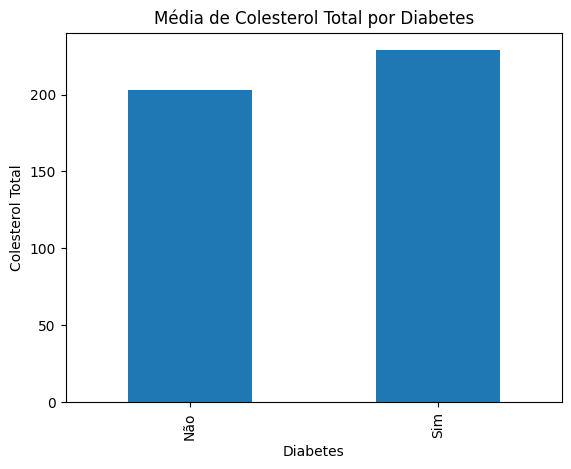

In [12]:
var = seletor.value

if var in colunas_categoricas:

    tabela = pd.crosstab(
        df[var],
        df['Diabetes'],
        normalize='index'
    ) * 100

    display(tabela)

    pd.crosstab(
        df[var],
        df['Diabetes']
    ).plot(kind='bar')

    plt.title(f'Diabete em relação a {var}')
    plt.xlabel(var)
    plt.ylabel('Quantidade')
    plt.show()


if var in colunas_numericas:

    tabela = df.groupby(
        'Diabetes'
    )[var].mean()

    display(tabela)

    tabela.plot(kind='bar')

    plt.title(f'Média de {var} por Diabetes')
    plt.xlabel('Diabetes')
    plt.ylabel(var)
    plt.show()

###### Variável x Variável

In [13]:
seletor_1 = widgets.Dropdown(
    options=colunas_numericas,
    description='Variável 1:'
)

seletor_2 = widgets.Dropdown(
    options=colunas_numericas,
    description='Variável 2:'
)

display(seletor_1, seletor_2)

Dropdown(description='Variável 1:', options=('Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Coles…

Dropdown(description='Variável 2:', options=('Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Coles…

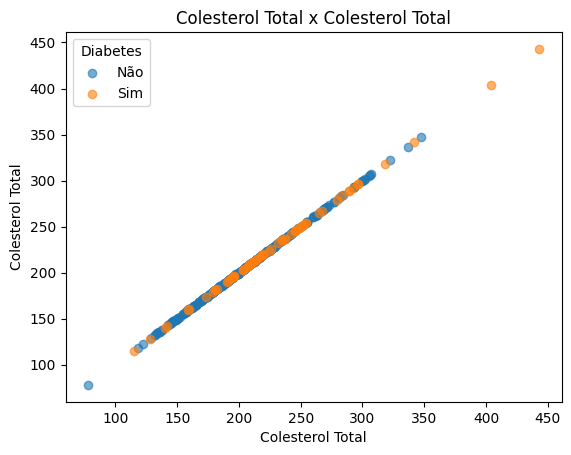

In [14]:
var_1 = seletor_1.value
var_2 = seletor_2.value

for grupo in ['Não', 'Sim']:
    dados = df[df['Diabetes'] == grupo]

    plt.scatter(
        dados[var_1],
        dados[var_2],
        label=grupo,
        alpha=0.6
    )

plt.title(f'{var_1} x {var_2}')
plt.xlabel(var_1)
plt.ylabel(var_2)
plt.legend(title='Diabetes')
plt.show()

###### Correlações

In [15]:
correlacoes = df.drop(columns=[
    'id',
    'Pressão Sistólica 2',
    'Pressão Diastólica 2'
]).corr(numeric_only=True)

display(correlacoes.round(2))


,Colesterol Total,Glicose Estabilizada,HDL,Relação Colesterol/HDL,glyhb,Idade,Altura,Peso,Pressão Sistólica 1,Pressão Diastólica 1,Cintura,Quadril,Tempo Após Refeição (min)
Colesterol Total,1.00,0.16,0.19,0.48,0.25,0.25,-0.07,0.06,0.21,0.17,0.13,0.09,0.01
Glicose Estabilizada,0.16,1.00,-0.16,0.28,0.75,0.29,0.10,0.19,0.16,0.02,0.22,0.14,-0.05
HDL,0.19,-0.16,1.00,-0.68,-0.15,0.03,-0.10,-0.29,0.03,0.08,-0.27,-0.22,0.07
Relação Colesterol/HDL,0.48,0.28,-0.68,1.00,0.33,0.16,0.09,0.28,0.11,0.04,0.31,0.20,-0.04
glyhb,0.25,0.75,-0.15,0.33,1.00,0.34,0.06,0.17,0.20,0.03,0.23,0.14,0.03
Idade,0.25,0.29,0.03,0.16,0.34,1.00,-0.09,-0.06,0.45,0.07,0.15,0.00,-0.04
Altura,-0.07,0.10,-0.10,0.09,0.06,-0.09,1.00,0.25,-0.05,0.04,0.05,-0.11,-0.01
Peso,0.06,0.19,-0.29,0.28,0.17,-0.06,0.25,1.00,0.10,0.17,0.85,0.83,-0.05
Pressão Sistólica 1,0.21,0.16,0.03,0.11,0.20,0.45,-0.05,0.10,1.00,0.60,0.21,0.15,-0.08
Pressão Diastólica 1,0.17,0.02,0.08,0.04,0.03,0.07,0.04,0.17,0.60,1.00,0.17,0.15,-0.07


In [16]:
seletor_3 = widgets.Dropdown(
    options=correlacoes.columns.tolist(),
    value='glyhb',
    description='Variável:'
)

print("Correlação com a variável selecionada:")
display(seletor_3)

Correlação com a variável selecionada:


Dropdown(description='Variável:', index=4, options=('Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relaçã…

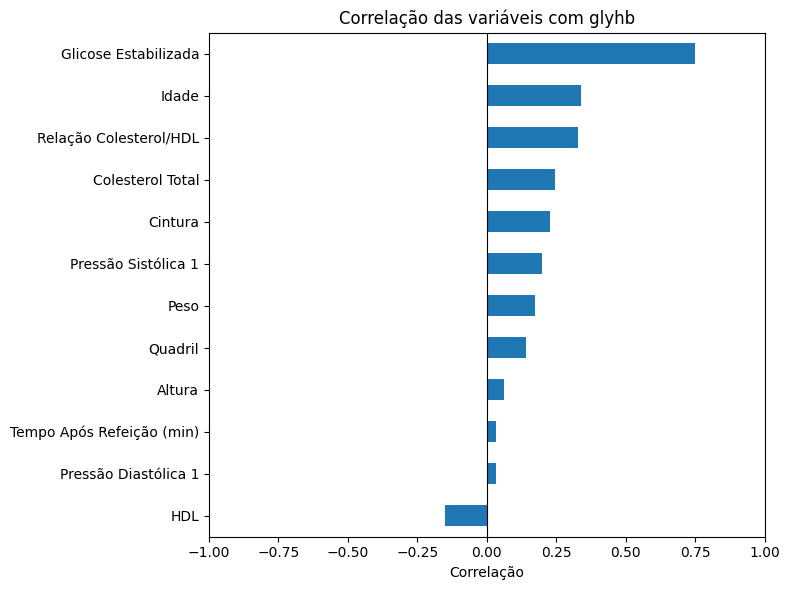

In [17]:
var_3 = seletor_3.value

correlacao = (
    correlacoes[var_3]
    .drop(var_3)
    .sort_values()
)

correlacao.plot(kind='barh', figsize=(8, 6))

plt.title(f'Correlação das variáveis com {var_3}')
plt.xlabel('Correlação')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

In [18]:
correlacao = correlacoes[var_3].drop(var_3)

ordem = correlacao.abs().sort_values(ascending=False).index

display(correlacao.loc[ordem])

,glyhb
Glicose Estabilizada,0.749236
Idade,0.338929
Relação Colesterol/HDL,0.328665
Colesterol Total,0.247099
Cintura,0.226184
Pressão Sistólica 1,0.197936
Peso,0.171882
HDL,-0.149145
Quadril,0.141401
Altura,0.063023


Considerações da análise exploratória
- Pessoas com diabetes apresentaram maior média de Glicose Estabilizada.
- Glicose Estabilizada e glyhb apresentaram forte correlação positiva (0,75).
- Peso, Cintura e Quadril apresentaram fortes correlações entre si (0,83 a 0,85), indicando possível redundância de informações.
- Essas relações ajudam a compreender os dados, mas não comprovam causalidade nem garantem bom desempenho dos modelos.
- A coluna glyhb será excluída do treinamento, pois foi usada para criar o alvo Diabetes.

#### Preparação do Dataset

- **Serão retiradas:** `id`, por ser apenas um identificador; `Localidade`, para priorizar características clínicas e corporais; e `Pressão Sistólica 2` e `Pressão Diastólica 2`, por apresentarem **252 valores ausentes cada**. `Gênero` e `Porte Corporal`, para simplificar a preparação e trabalhar apenas com variáveis numéricas; e `Tempo Após Refeição (min)`, por apresentar correlação linear muito baixa com `glyhb` (**0,03**).
- **`glyhb` será excluída das entradas dos modelos**, pois foi utilizada para criar o alvo `Diabetes`, evitando que o modelo receba a informação que define a resposta.

In [19]:
# Remove as colunas; ignora as que já foram retiradas
df = df.drop(columns=[
    'id',
    'Localidade',
    'Pressão Sistólica 2',
    'Pressão Diastólica 2',
    'Gênero',
    'Porte Corporal',
    'Tempo Após Refeição (min)',
    'glyhb'
], errors='ignore')

# Visualização da quantidade de valores nulos
df.isna().sum()

,0
Colesterol Total,1
Glicose Estabilizada,0
HDL,1
Relação Colesterol/HDL,1
Idade,0
Altura,5
Peso,1
Pressão Sistólica 1,5
Pressão Diastólica 1,5
Cintura,2


In [20]:
# Seleciona as variáveis, excluindo o alvo
dados_eda = df.drop(columns=['Diabetes'])

# Atualiza as lista
colunas = dados_eda.columns.tolist()

print("Todas:", colunas)

Todas: ['Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Colesterol/HDL', 'Idade', 'Altura', 'Peso', 'Pressão Sistólica 1', 'Pressão Diastólica 1', 'Cintura', 'Quadril']


Os valores ausentes serão estimados usando variáveis com maior **correlação em valor absoluto**, considerando também relações negativas:

- **Colesterol Total:** pela Relação Colesterol/HDL.
- **HDL e Relação Colesterol/HDL:** um pelo outro.
- **Peso:** pela Cintura.
- **Cintura e Quadril:** pelo Peso.
- **Pressões Sistólica e Diastólica:** uma pela outra.
- **Altura:** pela mediana do treino, pois apresenta correlações fracas.

Buscaremos no **treino** o registro com o valor de referência mais próximo e utilizaremos sua medida conhecida. Em caso de empate, calcularemos a média. Se a referência também estiver ausente, usaremos a mediana do treino. Essa estratégia será aplicada ao treino, à validação e ao teste, usando somente os dados originais do treino como referência, sem usar valores estimados como referência para outras estimativas.

In [21]:
# Reserva 20% para teste.
treino_base, teste_base = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['Diabetes']
)

# Reserva 20% do total para validação; ficam 60% para treino.
treino_base, validacao_base = train_test_split(
    treino_base,
    test_size=0.25,
    random_state=42,
    stratify=treino_base['Diabetes']
)

X_base = treino_base.drop(columns='Diabetes').copy()
y_treino = treino_base['Diabetes'].copy()

X_validacao_base = validacao_base.drop(columns='Diabetes').copy()
y_validacao = validacao_base['Diabetes'].copy()

X_teste_base = teste_base.drop(columns='Diabetes').copy()
y_teste = teste_base['Diabetes'].copy()

# Define a variável de referência para cada estimativa.
referencias = {
    'Colesterol Total': 'Relação Colesterol/HDL',
    'HDL': 'Relação Colesterol/HDL',
    'Relação Colesterol/HDL': 'HDL',
    'Peso': 'Cintura',
    'Pressão Sistólica 1': 'Pressão Diastólica 1',
    'Pressão Diastólica 1': 'Pressão Sistólica 1',
    'Cintura': 'Peso',
    'Quadril': 'Peso'
}

O dataset foi dividido em aproximadamente 60% para treinamento, 20% para validação e 20% para teste, preservando a proporção das classes. A validação será utilizada para escolher as configurações, e o teste será utilizado para avaliar os modelos escolhidos.

In [22]:
# Define o preenchimento uma única vez.
# A base fornece apenas valores originais, sem estimativas.
def preparar(base, dados):
    resultado = dados.copy()

    for coluna in base.columns:
        mediana = base[coluna].median()
        coluna_base = referencias.get(coluna)

        if coluna_base is not None:
            candidatos = base.dropna(subset=[coluna, coluna_base])

        for indice in dados.index[dados[coluna].isna()]:
            valor = mediana

            if coluna_base is not None:
                valor_base = dados.loc[indice, coluna_base]

                if pd.notna(valor_base) and not candidatos.empty:
                    diferenca = (
                        candidatos[coluna_base] - valor_base
                    ).abs()

                    valor = candidatos.loc[
                        diferenca == diferenca.min(), coluna
                    ].mean()

            resultado.loc[indice, coluna] = valor

    # Calcula o IMC depois de preencher Peso e Altura.
    peso_kg = resultado['Peso'] * 0.45359237
    altura_m = resultado['Altura'] * 0.0254
    resultado['IMC'] = peso_kg / altura_m ** 2

    return resultado

In [23]:
# Prepara os três grupos usando somente o treino como referência.
X_treino = preparar(X_base, X_base)
X_validacao = preparar(X_base, X_validacao_base)
X_teste = preparar(X_base, X_teste_base)

In [24]:
# Lista as entradas já preparadas, incluindo o IMC.
colunas = X_treino.columns.tolist()
print(colunas)

['Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Colesterol/HDL', 'Idade', 'Altura', 'Peso', 'Pressão Sistólica 1', 'Pressão Diastólica 1', 'Cintura', 'Quadril', 'IMC']


- **Peso e Altura:** serão retirados das entradas dos modelos para simplificar o conjunto, mantendo o **IMC**, que combina essas duas medidas. Ambos continuam sendo usados no cálculo do IMC.
- **Pressão Diastólica 1:** será retirada por apresentar baixa correlação linear com Diabetes no treino (**0,082**).
- **Quadril:** será retirado pela alta correlação com Cintura (**0,83**), indicando informações semelhantes. Manteremos Cintura por apresentar maior correlação com Diabetes (**0,225**, contra **0,109** do Quadril).

In [25]:
retirar = ['Peso', 'Altura', 'Pressão Diastólica 1', 'Quadril']
colunas = [coluna for coluna in colunas if coluna not in retirar]

print('Variáveis para os modelos:', colunas)

Variáveis para os modelos: ['Colesterol Total', 'Glicose Estabilizada', 'HDL', 'Relação Colesterol/HDL', 'Idade', 'Pressão Sistólica 1', 'Cintura', 'IMC']


## **Machine Learning**

### KNN

Para esta comparação, foram utilizados sete atributos na ordem apresentada abaixo. O HDL não foi incluído na busca, mantendo a Relação Colesterol/HDL, que incorpora essa medida. Essa escolha simplifica a comparação.

Foram comparados sete grupos de atributos, retirando a última variável a cada rodada. Esse procedimento compara grupos definidos pela ordem da lista, e não todas as combinações possíveis.

In [26]:
selecionadas = [
    'Glicose Estabilizada',
    'Colesterol Total',
    'IMC',
    'Pressão Sistólica 1',
    'Relação Colesterol/HDL',
    'Idade',
    'Cintura'
]

colunas_combinacao = selecionadas.copy()
resultados = []


Foram comparadas 28 configurações: sete grupos de atributos e quatro valores de k. A padronização foi aprendida exclusivamente no treino e aplicada à validação. A configuração foi escolhida pela maior acurácia balanceada, utilizando o F1 da classe “Sim” como critério de desempate.

In [27]:
while colunas_combinacao:
    # Aprende a padronização no treino e aplica à validação.
    normalizador = StandardScaler()
    entrada_treino = normalizador.fit_transform(
        X_treino[colunas_combinacao]
    )
    entrada_validacao = normalizador.transform(
        X_validacao[colunas_combinacao]
    )

    for k in [3, 5, 7, 9]:
        # Treina cada configuração.
        modelo = KNeighborsClassifier(n_neighbors=k)
        modelo.fit(entrada_treino, y_treino)

        # Compara na validação, sem usar o teste.
        previsoes = modelo.predict(entrada_validacao)

        resultados.append({
            'Quantidade de colunas': len(colunas_combinacao),
            'k': k,
            'Acurácia': accuracy_score(y_validacao, previsoes),
            'Balanceada': balanced_accuracy_score(
                y_validacao, previsoes
            ),
            'Recall-S': recall_score(
                y_validacao, previsoes,
                pos_label='Sim', zero_division=0
            ),
            'F1-S': f1_score(
                y_validacao, previsoes,
                pos_label='Sim', zero_division=0
            ),
            'Colunas': colunas_combinacao.copy()
        })

    # Retira a última coluna após testar todos os valores de k.
    colunas_combinacao.pop()

tabela = pd.DataFrame(resultados).sort_values(
    ['Balanceada', 'F1-S'], ascending=False
)

display(tabela.round(3))

# Escolhe pela maior balanceada e depois pelo maior F1.
melhor = tabela.iloc[0]
colunas_knn = melhor['Colunas']
k_knn = int(melhor['k'])

print('Colunas escolhidas:', colunas_knn)
print('k escolhido:', k_knn)

,Quantidade de colunas,k,Acurácia,Balanceada,Recall-S,F1-S,Colunas
1,7,5,0.949,0.877,0.769,0.833,"[Glicose Estabilizada, Colesterol Total, IMC, ..."
25,1,5,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
26,1,7,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
27,1,9,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
16,3,3,0.949,0.846,0.692,0.818,"[Glicose Estabilizada, Colesterol Total, IMC]"
21,2,5,0.949,0.846,0.692,0.818,"[Glicose Estabilizada, Colesterol Total]"
2,7,7,0.936,0.838,0.692,0.783,"[Glicose Estabilizada, Colesterol Total, IMC, ..."
3,7,9,0.936,0.838,0.692,0.783,"[Glicose Estabilizada, Colesterol Total, IMC, ..."
9,5,5,0.936,0.838,0.692,0.783,"[Glicose Estabilizada, Colesterol Total, IMC, ..."
22,2,7,0.936,0.838,0.692,0.783,"[Glicose Estabilizada, Colesterol Total]"


Colunas escolhidas: ['Glicose Estabilizada', 'Colesterol Total', 'IMC', 'Pressão Sistólica 1', 'Relação Colesterol/HDL', 'Idade', 'Cintura']
k escolhido: 5


Acurácia: 88.46%
Acurácia balanceada: 74.62%
              precision    recall  f1-score   support

         Não      0.912     0.954     0.932        65
         Sim      0.700     0.538     0.609        13

    accuracy                          0.885        78
   macro avg      0.806     0.746     0.771        78
weighted avg      0.876     0.885     0.878        78



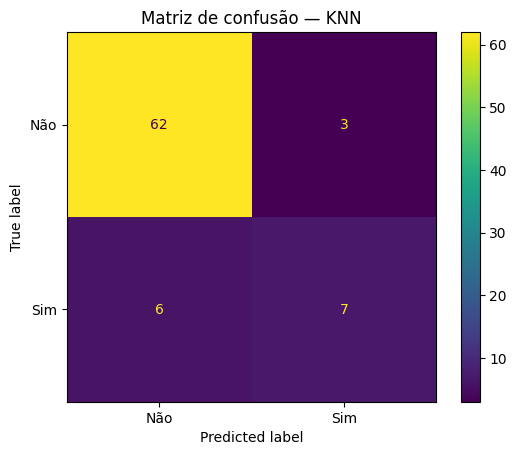

In [28]:
# Aprende a padronização no treino com as colunas escolhidas.
normalizador_knn = StandardScaler()

entrada_treino = normalizador_knn.fit_transform(
    X_treino[colunas_knn]
)
entrada_teste = normalizador_knn.transform(
    X_teste[colunas_knn]
)

# Treina o modelo escolhido pela validação.
modelo_knn = KNeighborsClassifier(n_neighbors=k_knn)
modelo_knn.fit(entrada_treino, y_treino)

# Avalia no teste.
previsoes_knn = modelo_knn.predict(entrada_teste)

print(f'Acurácia: {accuracy_score(y_teste, previsoes_knn):.2%}')
print(
    f'Acurácia balanceada: '
    f'{balanced_accuracy_score(y_teste, previsoes_knn):.2%}'
)

print(classification_report(
    y_teste, previsoes_knn,
    digits=3, zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes_knn,
    labels=['Não', 'Sim']
)

plt.title('Matriz de confusão — KNN')
plt.show()

O KNN com 5 vizinhos, utilizando os sete atributos selecionados, alcançou 88,46% de acurácia e 74,62% de acurácia balanceada no conjunto de teste. Identificou 7 dos 13 casos positivos, apresentando recall de 53,8% e F1 de 60,9% para a classe “Sim”. Apesar de superar a acurácia exigida, deixou de identificar 6 casos positivos.

### Random Forest

In [29]:
colunas_combinacao = selecionadas.copy()
resultados_rf = []

Foram comparadas 42 configurações: sete grupos de atributos, duas quantidades de árvores e três limites de profundidade. Não foi necessária padronização. A escolha utilizou os mesmos critérios empregados no KNN.

In [30]:
while colunas_combinacao:
    for arvores in [100, 200]:
        for profundidade in [None, 5, 10]:
            # Cria o modelo com os parâmetros desta rodada.
            # None permite árvores sem limite fixo de profundidade.
            modelo = RandomForestClassifier(
                n_estimators=arvores,
                max_depth=profundidade,
                random_state=42,
                n_jobs=-1
            )

            # Treina diretamente com os dados, sem padronização.
            modelo.fit(X_treino[colunas_combinacao], y_treino)

            # Compara na validação; o teste fica separado.
            previsoes = modelo.predict(X_validacao[colunas_combinacao])

            resultados_rf.append({
                'Quantidade de colunas': len(colunas_combinacao),
                'Árvores': arvores,
                'Profundidade': profundidade,
                'Acurácia': accuracy_score(y_validacao, previsoes),
                'Balanceada': balanced_accuracy_score(
                    y_validacao, previsoes
                ),
                'Recall-S': recall_score(
                    y_validacao, previsoes,
                    pos_label='Sim', zero_division=0
                ),
                'F1-S': f1_score(
                    y_validacao, previsoes,
                    pos_label='Sim', zero_division=0
                ),
                'Colunas': colunas_combinacao.copy()
            })

    # Retira a última coluna após testar os parâmetros.
    colunas_combinacao.pop()

tabela_rf = pd.DataFrame(resultados_rf).sort_values(
    ['Balanceada', 'F1-S'], ascending=False
)

display(tabela_rf.round(3))

# Guarda a configuração escolhida na validação.
melhor_rf = tabela_rf.iloc[0]
colunas_rf = melhor_rf['Colunas']
arvores_rf = int(melhor_rf['Árvores'])
profundidade_rf = (
    None if pd.isna(melhor_rf['Profundidade'])
    else int(melhor_rf['Profundidade'])
)

print('Colunas escolhidas:', colunas_rf)
print('Árvores:', arvores_rf)
print('Profundidade:', profundidade_rf)

,Quantidade de colunas,Árvores,Profundidade,Acurácia,Balanceada,Recall-S,F1-S,Colunas
36,1,100,NaN,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
37,1,100,5.0,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
38,1,100,10.0,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
39,1,200,NaN,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
40,1,200,5.0,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
41,1,200,10.0,0.949,0.877,0.769,0.833,[Glicose Estabilizada]
0,7,100,NaN,0.936,0.869,0.769,0.800,"[Glicose Estabilizada, Colesterol Total, IMC, ..."
1,7,100,5.0,0.936,0.869,0.769,0.800,"[Glicose Estabilizada, Colesterol Total, IMC, ..."
2,7,100,10.0,0.936,0.869,0.769,0.800,"[Glicose Estabilizada, Colesterol Total, IMC, ..."
3,7,200,NaN,0.936,0.869,0.769,0.800,"[Glicose Estabilizada, Colesterol Total, IMC, ..."


Colunas escolhidas: ['Glicose Estabilizada']
Árvores: 100
Profundidade: None


Acurácia: 91.03%
Acurácia balanceada: 79.23%
              precision    recall  f1-score   support

         Não      0.926     0.969     0.947        65
         Sim      0.800     0.615     0.696        13

    accuracy                          0.910        78
   macro avg      0.863     0.792     0.822        78
weighted avg      0.905     0.910     0.905        78



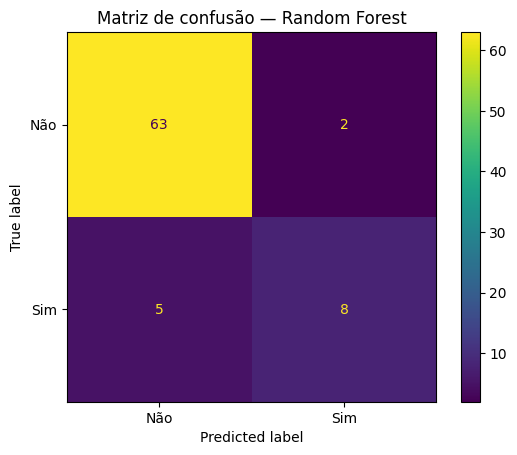

In [31]:
modelo_rf = RandomForestClassifier(
    n_estimators=arvores_rf,
    max_depth=profundidade_rf,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_treino[colunas_rf], y_treino)
previsoes_rf = modelo_rf.predict(X_teste[colunas_rf])

print(f'Acurácia: {accuracy_score(y_teste, previsoes_rf):.2%}')
print(
    f'Acurácia balanceada: '
    f'{balanced_accuracy_score(y_teste, previsoes_rf):.2%}'
)

print(classification_report(
    y_teste, previsoes_rf,
    digits=3, zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_teste, previsoes_rf,
    labels=['Não', 'Sim']
)

plt.title('Matriz de confusão — Random Forest')
plt.show()

O Random Forest alcançou 91,03% de acurácia e 79,23% de acurácia balanceada no conjunto de teste. O recall da classe “Sim” foi de 61,5%, identificando 8 dos 13 casos positivos, com F1 de 69,6%. O modelo superou a acurácia exigida e apresentou resultados superiores aos do KNN nesse teste, mas ainda deixou de identificar 5 casos positivos.

### Salvando Modelos

In [33]:
# Salva o KNN e os componentes necessários à preparação das entradas.
joblib.dump({
    'modelo': modelo_knn,
    'normalizador': normalizador_knn,
    'colunas': colunas_knn,
    'base_imputacao': X_base,
    'referencias': referencias
}, 'knn.joblib')

['knn.joblib']

In [34]:
# Random Forest não precisa de normalizador.
joblib.dump({
    'modelo': modelo_rf,
    'colunas': colunas_rf,
    'base_imputacao': X_base,
    'referencias': referencias
}, 'random_forest.joblib')

['random_forest.joblib']